In [65]:
import pandas as pd
import numpy as np
import matplotlib as plt
from statsmodels import robust

# Interquartile range
A common measurement of variability is the difference between the 25th percentile and the 75th percentile, called the interquartile range

In [66]:
data = {
    "State": [
        "Alabama",
        "Alaska",
        "Arizona",
        "Arkansas",
        "California",
        "Colorado",
        "Connecticut",
        "Delaware"
    ],
    "Population": [
        4779736,
        710231,
        6392017,
        2915918,
        37253956,
        5029196,
        3574097,
        897934
    ],
    "Murder rate": [
        5.7,
        5.6,
        4.7,
        5.6,
        4.4,
        2.8,
        2.4,
        5.8
    ],
    "Abbreviation": [
        "AL",
        "AK",
        "AZ",
        "AR",
        "CA",
        "CO",
        "CT",
        "DE"
    ]
}
df = pd.DataFrame(data)

In [67]:
df.head()

,State,Population,Murder rate,Abbreviation
0,Alabama,4779736,5.7,AL
1,Alaska,710231,5.6,AK
2,Arizona,6392017,4.7,AZ
3,Arkansas,2915918,5.6,AR
4,California,37253956,4.4,CA


In [68]:
print(df['Population'].mean())
print(df['Population'].median())
print(f"{df['Population'].std():.2f}")
print(f"{df['Population'].var():.2f}")

7694135.625
4176916.5
12105745.30
146549069168147.69


In [69]:
iqr = df['Population'].quantile(0.75) - df['Population'].quantile(0.25)

In [70]:
print(iqr)

2958479.25


# Median Absolute Deviation [MAD]

More robust metrics include mean absolute deviation, median absolute deviation from the median, and percentiles (quantiles)

In [71]:
print(sm.robust.scale.mad(df['Population']))

NameError: name 'sm' is not defined

# Outliers Based on IQR

In [73]:
df = pd.DataFrame({
    "Student": [
        "A","B","C","D","E","F","G","H","I","J",
        "K","L","M","N","O","P","Q","R","S"
    ],
    "Study_Hours": [
        2, 3, 4, 5, 5, 6, 6, 7, 7, 8,
        8, 9, 10, 10, 11, 12, 13, 14, 25
    ],
    "Exam_Score": [
        45, 50, 52, 55, 57, 60, 62, 65, 66, 68,
        70, 72, 75, 77, 80, 82, 84, 86, 98
    ]
})

df.head()

,Student,Study_Hours,Exam_Score
0,A,2,45
1,B,3,50
2,C,4,52
3,D,5,55
4,E,5,57


In [74]:
Q1 = df["Exam_Score"].quantile(0.25)
Q3 = df["Exam_Score"].quantile(0.75)
IQR_Exam_Scores = Q3 - Q1

In [75]:
lower = Q1 - IQR_Exam_Scores
higher = Q3 + IQR_Exam_Scores

In [76]:
print(lower)
print(higher)

38.5
98.5


In [77]:
outliers = df[
    (df["Exam_Score"] < lower) | 
    (df["Exam_Score"] > higher)
]
# Exactly what the boxplot uses internally.
# Remember : | has higher precedence than < and >

In [78]:
outliers.head()

,Student,Study_Hours,Exam_Score


# Skewness

<Axes: >

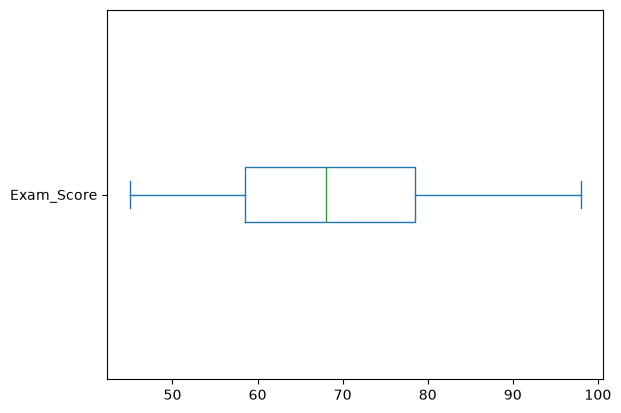

In [79]:
df["Exam_Score"].plot.box(vert = False) # Horizontal Box Plot

In [80]:
print(df["Exam_Score"].skew())

0.22158161507510735


# Properties of skew : 

Negative Skew : 
1. The Mean is Pulled Downward
2. longer left tail
3. Mean < Median
4. Outliers can Significantly skew the data

Positive Skew : The Mean is Pulled Upward, longer right tail
1. The Mean is Pulled Upward
2. longer Right tail
3. Mean > Median
4. Outliers can Significantly skew the data

# Kurtosis
Kurtosis measures how likely a distribution is to produce extreme values (outliers).

In [81]:
print(df["Exam_Score"].kurt())

-0.41661451888018286
